## Hadamard and Hadamard like Gates
The Hadamard gate (H) is a fundamental single-qubit gate that maps computational basis states to equal superpositions:
$$H
    \ket{0} = \frac{\ket{0} + \ket{1}}{\sqrt{2}}, \quad H\ket{1} = \frac{\ket{0} - \ket{1}}{\sqrt{2}}
$$
- Matrix representation: $H = \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\ 1 & -1\end{pmatrix}$
- Equivalent rotation (up to global phase): $H \sim R_z(\pi) R_y(\pi/2)$
- Maps Z-axis states $(\ket{0}, \ket{1})$ to X-axis states on the Bloch sphere $(\ket{+}, \ket{-})$.

In [27]:
# Imports and helper functions
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector


# Simulator
sim = AerSimulator()

# Function to get the statevector after evolving
def get_statevector(qc, initial_sv=None):
    if initial_sv is None:
        initial_sv = Statevector.from_label('0')
    return initial_sv.evolve(qc)

In [28]:
# Apply Hadamard to |0> and |1>
bases = {'|0>': Statevector.from_label('0'),
         '|1>': Statevector.from_label('1')}

for label, sv in bases.items():
    qc = QuantumCircuit(1)
    qc.h(0)
    out_sv = sv.evolve(qc)
    print(f"{label} after H: {np.round(out_sv.data, 6)}")
    plot_bloch_multivector(out_sv)

|0> after H: [0.707107+0.j 0.707107+0.j]
|1> after H: [ 0.707107+0.j -0.707107+0.j]


In [29]:
# Numeric check: H vs equivalent rotations
test_sv = Statevector.from_label('0')
qc_h = QuantumCircuit(1); qc_h.h(0)
qc_rot = QuantumCircuit(1); qc_rot.ry(np.pi/2,0); qc_rot.rz(np.pi,0)
sv_h = test_sv.evolve(qc_h)
sv_rot = test_sv.evolve(qc_rot)

overlap = np.vdot(sv_h.data, sv_rot.data)
print("Overlap magnitude:", np.abs(overlap), "Phase:", np.angle(overlap))

Overlap magnitude: 6.123233995736766e-17 Phase: 0.0


| Property | Description |
|---------------------------|------------|
| Involution | H² = I (self-inverse) |
| Maps Z-basis to X-basis | H|0> = |+>, H|1> = |-> |
| Superposition creation | Converts computational basis into equal superposition |
| Use in algorithms | Basis for quantum Fourier transform, Deutsch-Jozsa, Grover’s algorithm |

### Hadarmard-like Gates:
Hadamard-like gates are generalizations of the standard Hadamard that rotate qubits into superposition states along different axes:

| Gate   | Effect                                                                 |
|--------|------------------------------------------------------------------------|
| H_y    | Maps $\ket{0}$ to a superposition along **Y-axis** of the Bloch sphere, with phase i. |
| H_y†   | Inverse of H_y, rotates opposite along Y-axis.                         |
| H_x    | Maps $\ket{0}$ to a superposition along **X-axis** with different phase factors. |
| H_x†   | Inverse of H_x, rotates opposite along X-axis.                         |

**Key points:**

- Like the Hadamard gate, they are unitary and self-inverse in pairs (e.g., $H_y^\dagger$ is the inverse of $H_y$).  
- They allow us to prepare superposition states along axes other than X, which is useful for certain quantum algorithms or for visualising rotations around Y or X.  
- On the Bloch sphere, they rotate the $\ket{0}$ vector away from the Z-axis toward another axis (X or Y), similar to how $H$ rotates $\ket{0}$ to $\ket{+}$ on the X-axis.

In [30]:
# Hadamard-like gates section
# Example: H_y, H_x and pseudo-Hadamard variations
hadamard_like_gates = {
    'H_y': {'matrix': np.array([[1, 1j],[1j, 1]])/np.sqrt(2), 'rotation': 'Ry+Rz'},
    'H_y†': {'matrix': np.array([[1, -1j],[-1j, 1]])/np.sqrt(2), 'rotation': 'Ry-Rz'},
    'H_x': {'matrix': np.array([[1+1j, 1-1j],[1-1j, 1+1j]])/2, 'rotation': 'Rx+Rz'},
    'H_x†': {'matrix': np.array([[1-1j, 1+1j],[1+1j, 1-1j]])/2, 'rotation': 'Rx-Rz'}
}

In [31]:
# Function to apply and visualise
for label, info in hadamard_like_gates.items():
    qc = QuantumCircuit(1)
    # Use unitary gate (matrix) to apply
    from qiskit.quantum_info import Operator
    qc.unitary(Operator(info['matrix']), [0])
    sv_out = Statevector.from_label('0').evolve(qc)
    print(f"{label} output statevector: {np.round(sv_out.data,6)}")
    plot_bloch_multivector(sv_out)

H_y output statevector: [0.707107+0.j       0.      +0.707107j]
H_y† output statevector: [0.707107+0.j       0.      -0.707107j]
H_x output statevector: [0.5+0.5j 0.5-0.5j]
H_x† output statevector: [0.5-0.5j 0.5+0.5j]


H_y output statevector: [0.707107+0.j       0.      +0.707107j]
H_y† output statevector: [0.707107+0.j       0.      -0.707107j]
H_x output statevector: [0.5+0.5j 0.5-0.5j]
H_x† output statevector: [0.5-0.5j 0.5+0.5j]


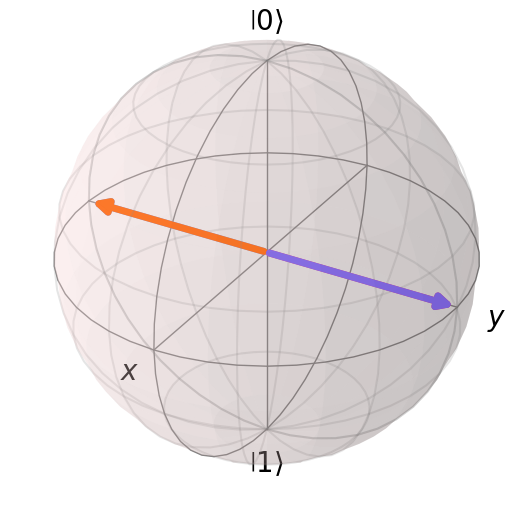

In [33]:
from qiskit.visualization.bloch import Bloch

# Function to get Bloch vector
def bloch_vector(sv: Statevector):
    alpha, beta = sv.data
    x = 2 * np.real(np.conj(alpha) * beta)
    y = 2 * np.imag(np.conj(alpha) * beta)
    z = np.abs(alpha)**2 - np.abs(beta)**2
    return [x, y, z]

# Colors for each vector
colors = {
    'H_y': 'red',
    'H_y†': 'orange',
    'H_x': 'blue',
    'H_x†': 'green'
}

# Initialize Bloch sphere
b = Bloch()

# Starting from |0>
initial_sv = Statevector.from_label('0')

# Evolve each gate and add its Bloch vector
for label, info in hadamard_like_gates.items():
    qc = QuantumCircuit(1)
    mat = info['matrix']
    qc.unitary(Operator(mat.astype(complex)), [0])
    
    sv_out = initial_sv.evolve(qc)
    print(f"{label} output statevector: {np.round(sv_out.data,6)}")
    
    # Convert statevector to Bloch vector
    b.add_vectors(bloch_vector(sv_out))
    b.vector_color.append(colors[label])
    
b.title = "All Hadamard-like gate outputs from |0>"
b.show()